In [13]:
import pandas as pd
import joblib


model = joblib.load('../saved_models/final_model.pkl')
data = pd.read_csv('../data/Model_Training.csv')


leakage_cols = ['days_since_last_transaction_x', 'days_since_last_transaction_y']
data = data.drop(columns=leakage_cols)

user_ids = data[['user_id', 'index']].copy()

X = data.drop(columns=['user_id', 'index', 'is_active'])
y = data['is_active']


In [14]:
X

,total_transactions,active_days,unique_merchants,days_between_first_and_last_txn,age_group_16-18,age_group_19-22,age_group_23-30,age_group_31+,most_common_payment_method_UPI,most_common_transaction_type_Education,most_common_transaction_type_Entertainment,most_common_transaction_type_Food,most_common_transaction_type_Other,most_common_transaction_type_Shopping,most_common_transaction_type_Travel
0,18.0,13.0,12.0,29.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,2.0,2.0,4.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,7.0,6.0,7.0,30.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,2.0,2.0,2.0,12.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,9.0,8.0,8.0,20.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
463303,19.0,14.0,15.0,30.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
463304,14.0,11.0,13.0,28.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
463305,11.0,11.0,7.0,26.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
463306,6.0,6.0,5.0,24.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


In [15]:
import shap
import matplotlib.pyplot as plt

explainer = shap.Explainer(model)
shap_values = explainer(X)


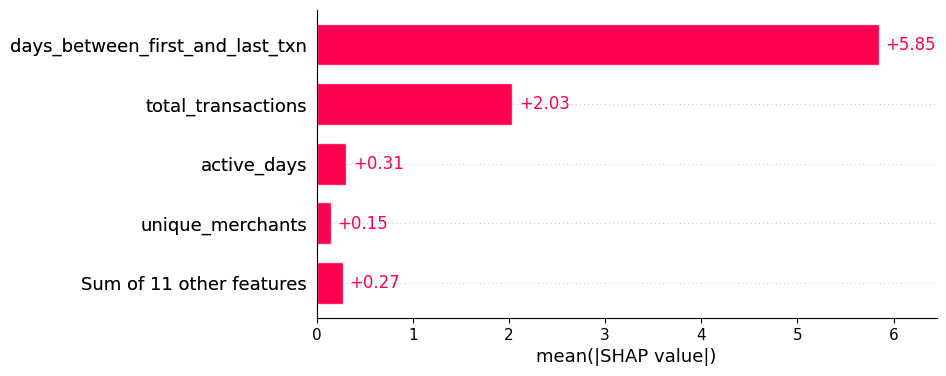

In [3]:
shap.plots.bar(shap_values, max_display=5)

- days_between_first_and_last_txn is the strongest driver of churn if there is a large gap between a user first and last transaction -> inactivity / drop in engagement.

- total_transactions counts are linked with higher churn risk i.e users with fewer total purchases prone to leaving.

- Fewer active days increase churn likelihood.

- Customers transacting with a limited number of merchants may churn.

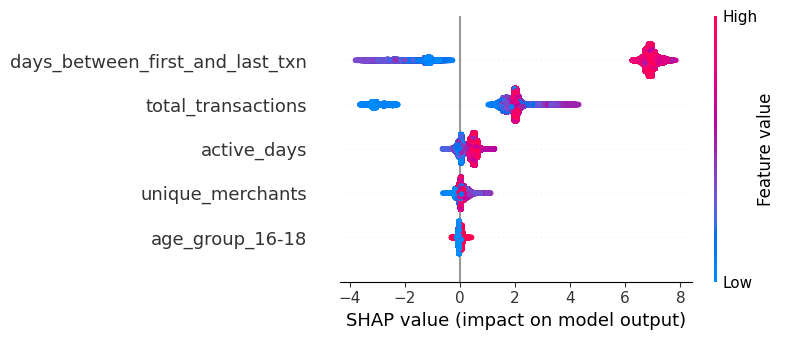

In [16]:
shap.summary_plot(shap_values, X, max_display=5)


### This tells about the value that whats the valuea and its impact on churn

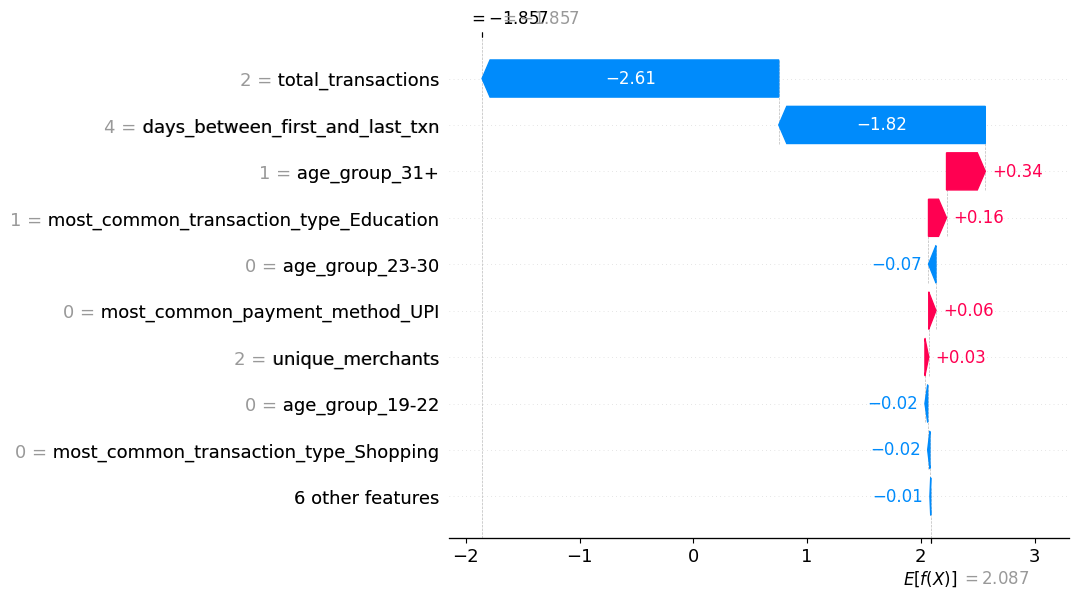

In [17]:
churned_index = y[y == 0].index[0]

shap.plots.waterfall(shap_values[churned_index])


### E[f(X)] = 2.087 (log -odds)is the average model prediction across all users, but decreases the prediction to –1.857 because of this specific feature contribution

- total_transactions shows very strong negative contribution → High churn risk due to few transactions, then for days_between_first_and_last_txn

In [18]:
def assign_churn_risk(prob):
    if prob > 0.7:
        return 'High-risk'
    elif prob >= 0.3:
        return 'Medium-risk'
    else:
        return 'Low-risk'

In [19]:
X['churn_probability'] = model.predict_proba(X)[:, 0]  

In [20]:
X['churn_risk_segment'] = X['churn_probability'].apply(assign_churn_risk)

In [22]:
output_df = user_ids.copy()
output_df['churn_probability'] = X['churn_probability']
output_df['churn_risk_segment'] = X['churn_risk_segment']

In [24]:
output_df.to_csv('../output/final_churn_risk.csv', index=False)